/var/folders/6z/0zwcwb493_l2wdptb7yp4n2c0000gn/T/ipykernel_10614/4227662210.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0, 0], x='plan_tier', y='churn_flag', data=df, palette='viridis', errorbar=None)
/var/folders/6z/0zwcwb493_l2wdptb7yp4n2c0000gn/T/ipykernel_10614/4227662210.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, 0].set_xticklabels(['Basic (0)', 'Pro (1)', 'Enterprise (2)'])
/var/folders/6z/0zwcwb493_l2wdptb7yp4n2c0000gn/T/ipykernel_10614/4227662210.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[0, 1], x='churn_flag', y='seats', data=df, palette=['#2ecc7

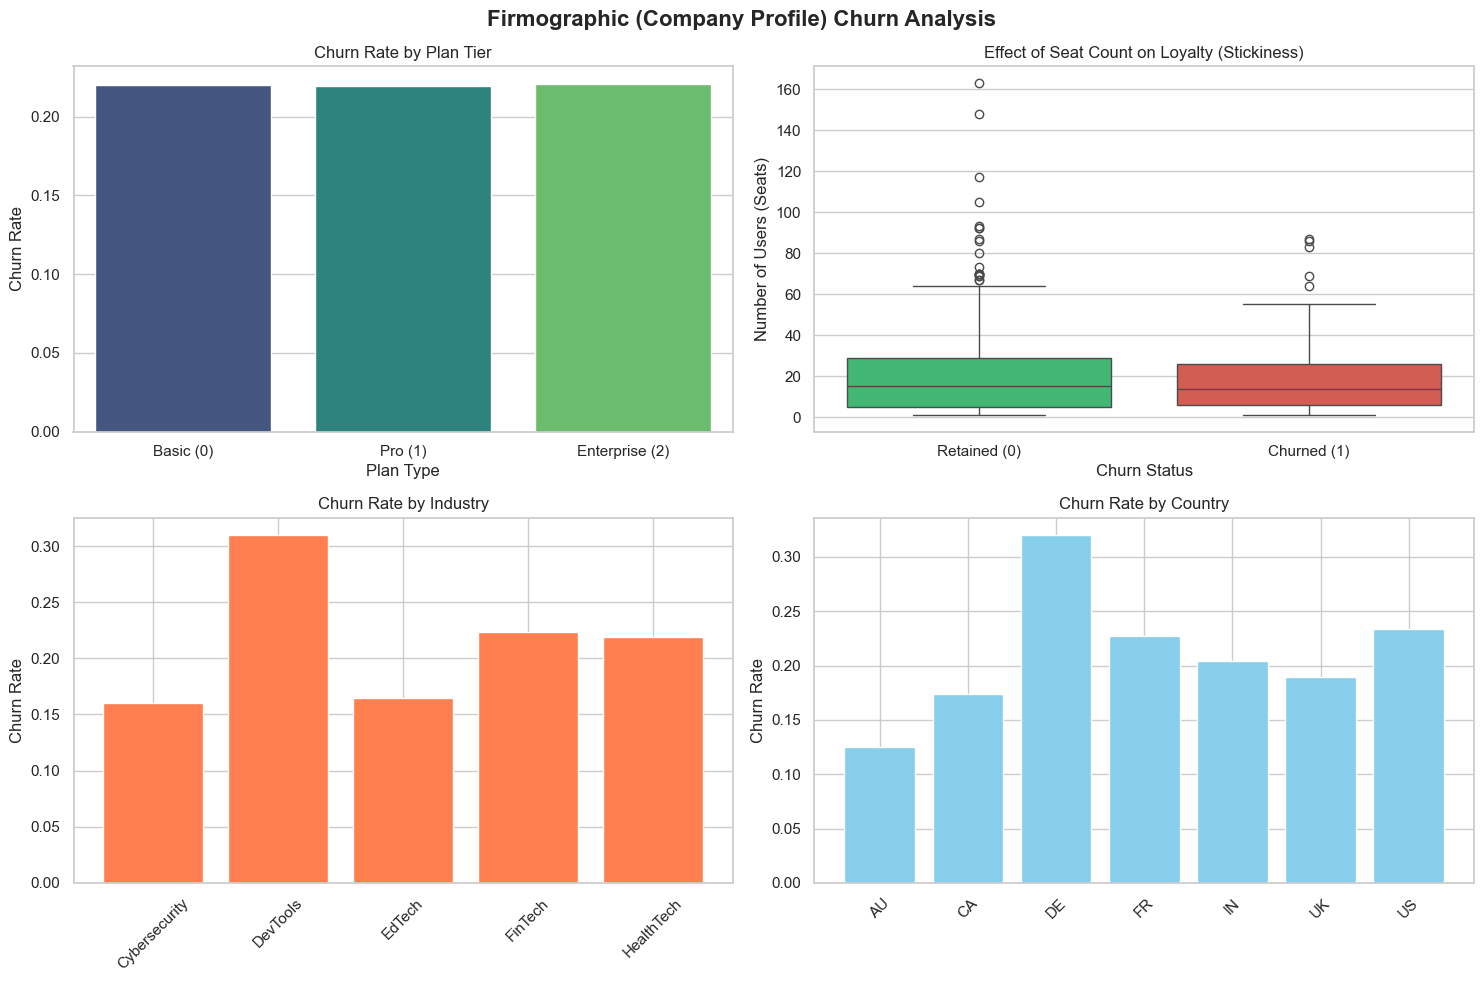

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Theme settings
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (15, 10)

# Load Data
processed_path = "../data/processed"
df = pd.read_csv(f"{processed_path}/master_features_final.csv")

fig, axes = plt.subplots(2, 2)
fig.suptitle("Firmographic (Company Profile) Churn Analysis", fontsize=16, fontweight='bold')

# ==========================================
# 1. CHURN BY PLAN TIER (Bar Plot)
# ==========================================
# 0: Basic, 1: Pro, 2: Enterprise
sns.barplot(ax=axes[0, 0], x='plan_tier', y='churn_flag', data=df, palette='viridis', errorbar=None)
axes[0, 0].set_title("Churn Rate by Plan Tier")
axes[0, 0].set_xticklabels(['Basic (0)', 'Pro (1)', 'Enterprise (2)'])
axes[0, 0].set_ylabel("Churn Rate")
axes[0, 0].set_xlabel("Plan Type")

# ==========================================
# 2. CHURN BY NUMBER OF SEATS (Box Plot)
# ==========================================
sns.boxplot(ax=axes[0, 1], x='churn_flag', y='seats', data=df, palette=['#2ecc71', '#e74c3c'])
axes[0, 1].set_title("Effect of Seat Count on Loyalty (Stickiness)")
axes[0, 1].set_xticklabels(['Retained (0)', 'Churned (1)'])
axes[0, 1].set_ylabel("Number of Users (Seats)")
axes[0, 1].set_xlabel("Churn Status")

# ==========================================
# 3. CHURN BY INDUSTRY (Aggregating Dummy Variables)
# ==========================================
industry_cols = [col for col in df.columns if col.startswith('industry_')]
ind_churn = {col.replace('industry_', ''): df[df[col] == 1]['churn_flag'].mean() for col in industry_cols}

axes[1, 0].bar(ind_churn.keys(), ind_churn.values(), color='coral')
axes[1, 0].set_title("Churn Rate by Industry")
axes[1, 0].set_ylabel("Churn Rate")
axes[1, 0].tick_params(axis='x', rotation=45)

# ==========================================
# 4. CHURN BY COUNTRY (Aggregating Dummy Variables)
# ==========================================
country_cols = [col for col in df.columns if col.startswith('country_')]
country_churn = {col.replace('country_', ''): df[df[col] == 1]['churn_flag'].mean() for col in country_cols}

axes[1, 1].bar(country_churn.keys(), country_churn.values(), color='skyblue')
axes[1, 1].set_title("Churn Rate by Country")
axes[1, 1].set_ylabel("Churn Rate")
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

/var/folders/6z/0zwcwb493_l2wdptb7yp4n2c0000gn/T/ipykernel_10614/726895366.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='churn_flag', y='avg_session_duration',
/var/folders/6z/0zwcwb493_l2wdptb7yp4n2c0000gn/T/ipykernel_10614/726895366.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Retained (0)', 'Churned (1)'])
/var/folders/6z/0zwcwb493_l2wdptb7yp4n2c0000gn/T/ipykernel_10614/726895366.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='churn_flag', y='total_usage_count',
/var/folders/6z/0zwcwb493_l2wdptb7yp4n2c0000gn/T/ipykernel_10614/726895366

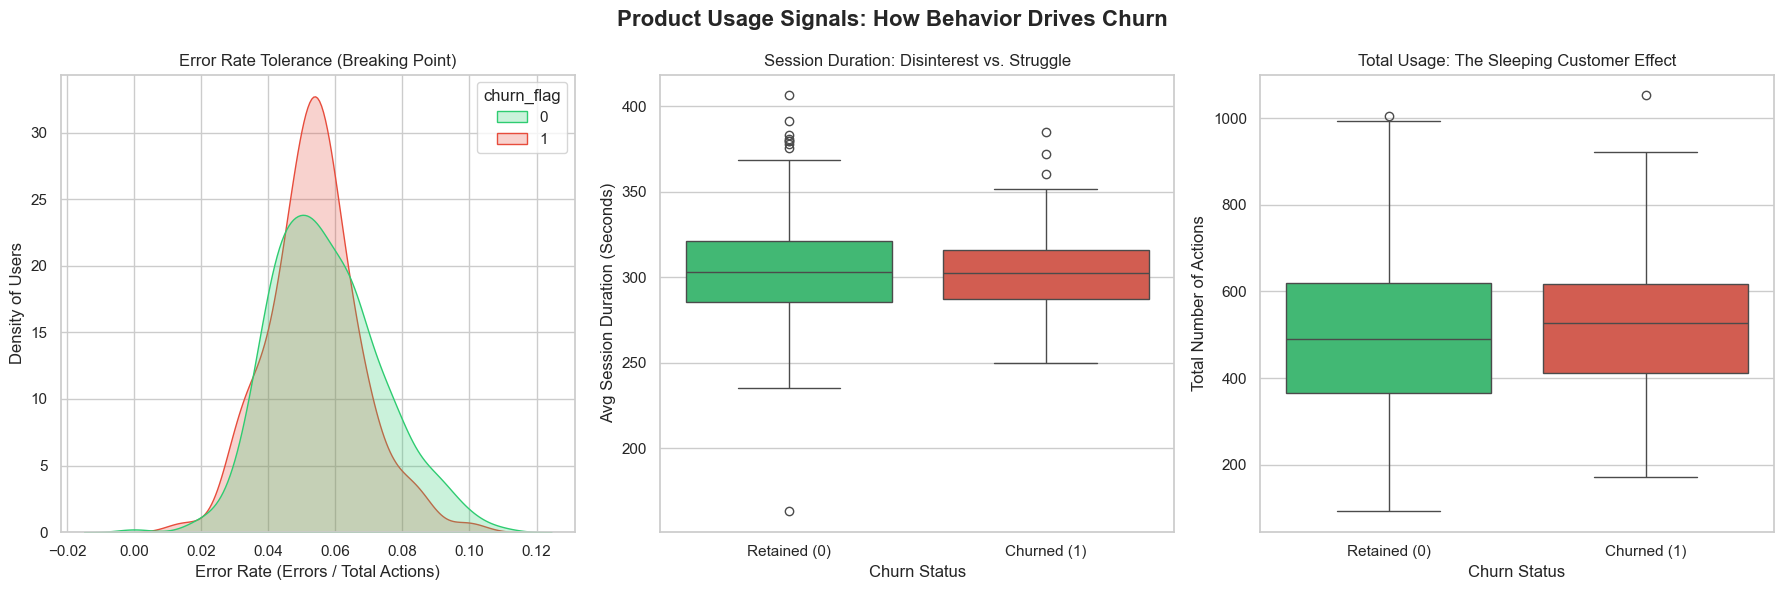

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Theme and figure size settings
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Product Usage Signals: How Behavior Drives Churn", fontsize=16, fontweight='bold')

# Load the master data
processed_path = "../data/processed"
df = pd.read_csv(f"{processed_path}/master_features_final.csv")

# ==========================================
# 1. ERROR RATE DISTRIBUTION & THRESHOLD (KDE Plot)
# ==========================================
# KDE (Kernel Density Estimation) shows where the concentration of users is.
# Perfect for finding exact breaking points (thresholds).
sns.kdeplot(data=df, x='error_rate', hue='churn_flag', fill=True, 
            common_norm=False, palette=['#2ecc71', '#e74c3c'], ax=axes[0])
axes[0].set_title("Error Rate Tolerance (Breaking Point)")
axes[0].set_xlabel("Error Rate (Errors / Total Actions)")
axes[0].set_ylabel("Density of Users")

# ==========================================
# 2. AVERAGE SESSION DURATION (Box Plot)
# ==========================================
# Are they leaving because they can't find things (short) or struggling (long)?
sns.boxplot(data=df, x='churn_flag', y='avg_session_duration', 
            palette=['#2ecc71', '#e74c3c'], ax=axes[1])
axes[1].set_title("Session Duration: Disinterest vs. Struggle")
axes[1].set_xticklabels(['Retained (0)', 'Churned (1)'])
axes[1].set_ylabel("Avg Session Duration (Seconds)")
axes[1].set_xlabel("Churn Status")

# ==========================================
# 3. TOTAL USAGE COUNT (Box Plot)
# ==========================================
# Investigating the "Sleeping Customer" effect.
sns.boxplot(data=df, x='churn_flag', y='total_usage_count', 
            palette=['#2ecc71', '#e74c3c'], ax=axes[2])
axes[2].set_title("Total Usage: The Sleeping Customer Effect")
axes[2].set_xticklabels(['Retained (0)', 'Churned (1)'])
axes[2].set_ylabel("Total Number of Actions")
axes[2].set_xlabel("Churn Status")

plt.tight_layout()
plt.show()

/var/folders/6z/0zwcwb493_l2wdptb7yp4n2c0000gn/T/ipykernel_10614/831448359.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[0], data=df, x='churn_flag', y='escalation_rate', palette=['#2ecc71', '#e74c3c'])
/var/folders/6z/0zwcwb493_l2wdptb7yp4n2c0000gn/T/ipykernel_10614/831448359.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Retained (0)', 'Churned (1)'])
/var/folders/6z/0zwcwb493_l2wdptb7yp4n2c0000gn/T/ipykernel_10614/831448359.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[1], x='provided_satisfaction_score', y='churn_flag', data=df, palette='viri

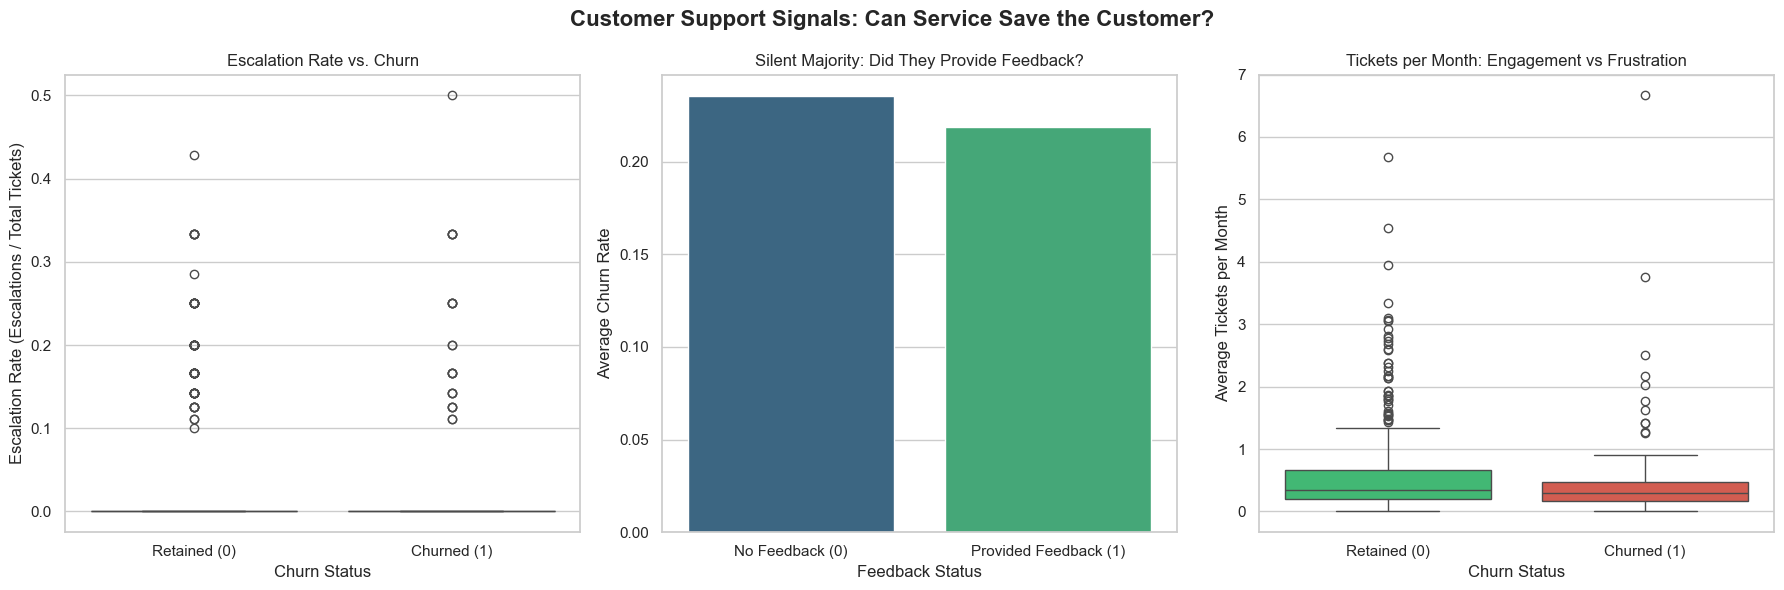

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Theme and figure size settings
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Customer Support Signals: Can Service Save the Customer?", fontsize=16, fontweight='bold')

# Load Data
processed_path = "../data/processed"
df = pd.read_csv(f"{processed_path}/master_features_final.csv")

# ==========================================
# 1. ESCALATION RATE (Box Plot)
# ==========================================
# Does escalating a ticket to a manager mean the customer is already lost?
sns.boxplot(ax=axes[0], data=df, x='churn_flag', y='escalation_rate', palette=['#2ecc71', '#e74c3c'])
axes[0].set_title("Escalation Rate vs. Churn")
axes[0].set_xticklabels(['Retained (0)', 'Churned (1)'])
axes[0].set_ylabel("Escalation Rate (Escalations / Total Tickets)")
axes[0].set_xlabel("Churn Status")

# ==========================================
# 2. PROVIDED SATISFACTION: THE SILENT MAJORITY (Bar Plot)
# ==========================================
# Are those who don't leave feedback more dangerous?
sns.barplot(ax=axes[1], x='provided_satisfaction_score', y='churn_flag', data=df, palette='viridis', errorbar=None)
axes[1].set_title("Silent Majority: Did They Provide Feedback?")
axes[1].set_xticklabels(['No Feedback (0)', 'Provided Feedback (1)'])
axes[1].set_ylabel("Average Churn Rate")
axes[1].set_xlabel("Feedback Status")

# ==========================================
# 3. TICKETS PER MONTH (Box Plot)
# ==========================================
# Are many tickets a sign of engagement or extreme frustration?
sns.boxplot(ax=axes[2], data=df, x='churn_flag', y='ticket_per_month', palette=['#2ecc71', '#e74c3c'])
axes[2].set_title("Tickets per Month: Engagement vs Frustration")
axes[2].set_xticklabels(['Retained (0)', 'Churned (1)'])
axes[2].set_ylabel("Average Tickets per Month")
axes[2].set_xlabel("Churn Status")

plt.tight_layout()
plt.show()

/var/folders/6z/0zwcwb493_l2wdptb7yp4n2c0000gn/T/ipykernel_10614/1128379041.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[0], data=df, x='churn_flag', y='total_mrr', palette=['#2ecc71', '#e74c3c'])
/var/folders/6z/0zwcwb493_l2wdptb7yp4n2c0000gn/T/ipykernel_10614/1128379041.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Retained (0)', 'Churned (1)'])
/var/folders/6z/0zwcwb493_l2wdptb7yp4n2c0000gn/T/ipykernel_10614/1128379041.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[1], x='total_upgrades', y='churn_flag', data=df, palette='viridis', errorbar=N

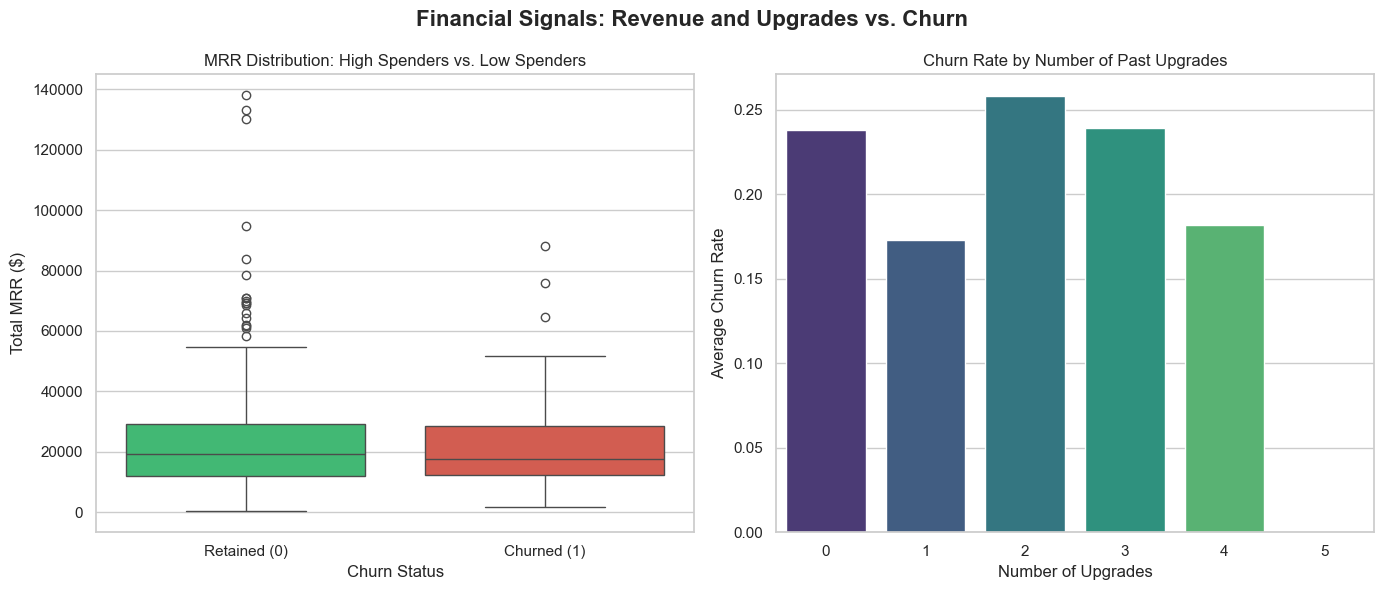

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Theme and figure size settings
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Financial Signals: Revenue and Upgrades vs. Churn", fontsize=16, fontweight='bold')

# Load Data
processed_path = "../data/processed"
df = pd.read_csv(f"{processed_path}/master_features_final.csv")

# ==========================================
# 1. TOTAL MRR (Box Plot)
# ==========================================
# Are we losing high-value whales or low-value small fish?
sns.boxplot(ax=axes[0], data=df, x='churn_flag', y='total_mrr', palette=['#2ecc71', '#e74c3c'])
axes[0].set_title("MRR Distribution: High Spenders vs. Low Spenders")
axes[0].set_xticklabels(['Retained (0)', 'Churned (1)'])
axes[0].set_ylabel("Total MRR ($)")
axes[0].set_xlabel("Churn Status")

# ==========================================
# 2. TOTAL UPGRADES (Bar Plot)
# ==========================================
# Does upgrading a plan in the past guarantee future loyalty?
sns.barplot(ax=axes[1], x='total_upgrades', y='churn_flag', data=df, palette='viridis', errorbar=None)
axes[1].set_title("Churn Rate by Number of Past Upgrades")
axes[1].set_ylabel("Average Churn Rate")
axes[1].set_xlabel("Number of Upgrades")

plt.tight_layout()
plt.show()